In [ ]:
# basic modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# train test split
from sklearn.model_selection import train_test_split

# preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

# linear regression
from sklearn.linear_model import LinearRegression

# XGBOOST
from xgboost import XGBClassifier
from xgboost import XGBRegressor

# random forest classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

# permutation importance
from sklearn.inspection import permutation_importance

# shap
import shap

# metrics
from sklearn.metrics import silhouette_score
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import sys


# graphics
from sklearn.tree import plot_tree

# settings
pd.set_option('display.float_format', '{:.2f}'.format)

In [5]:
# load data

df = pd.read_csv(
    "C:/Users/heike/Desktop/Stackfuel/Portfolio/llm-sustainability-analysis/01_data/03_features/conversation_features_target.csv"
)

print(df.shape)

(57529, 32)


In [6]:
df.columns

Index(['conversation_id', 'first_prompt', 'first_response',
       'first_prompt_tokens', 'first_response_tokens', 'total_turns',
       'interaction_rounds', 'total_user_tokens', 'total_assistant_tokens',
       'total_tokens', 'log_total_tokens', 'follow_up_prompts',
       'needs_follow_up', 'has_role_instruction',
       'has_audience_or_level_instruction', 'has_format_instruction',
       'question_count', 'prompt_style', 'task_type',
       'orthographic_error_rate', 'topic', 'topic_prob', 'topic_label',
       'embedding_novelty', 'topic_confidence', 'is_generic_topic',
       'topic_size', 'topic_size_log', 'target_cost', 'target_success',
       'topic_name', 'target_cost_log'],
      dtype='str')

In [7]:
df.dtypes

conversation_id                          str
first_prompt                             str
first_response                           str
first_prompt_tokens                    int64
first_response_tokens                  int64
total_turns                            int64
interaction_rounds                   float64
total_user_tokens                      int64
total_assistant_tokens                 int64
total_tokens                           int64
log_total_tokens                     float64
follow_up_prompts                      int64
needs_follow_up                        int64
has_role_instruction                   int64
has_audience_or_level_instruction      int64
has_format_instruction                 int64
question_count                         int64
prompt_style                             str
task_type                                str
orthographic_error_rate              float64
topic                                  int64
topic_prob                           float64
topic_labe

In [ ]:
# dtypes    ### !!! auch in feature_target... könnte bei neuem Durchlaufen entfernt werden.

df["prompt_style"]=df["prompt_style"].astype("category")
df["task_type"]=df["task_type"].astype("category")
df["target_success"]=df["target_success"].astype("int")

#df.dtypes

In [19]:
# filter other languages with orthographic error rate

OER = 0.40

outliers_oer = df[df["orthographic_error_rate"] > OER]   
print(outliers_oer)    # n=247

# print

pd.set_option("display.max_rows", None)


df = df[df["orthographic_error_rate"] < OER]
print(len(df))    # n=247


Empty DataFrame
Columns: [conversation_id, first_prompt, first_response, first_prompt_tokens, first_response_tokens, total_turns, interaction_rounds, total_user_tokens, total_assistant_tokens, total_tokens, log_total_tokens, follow_up_prompts, needs_follow_up, has_role_instruction, has_audience_or_level_instruction, has_format_instruction, question_count, prompt_style, task_type, orthographic_error_rate, topic, topic_prob, topic_label, embedding_novelty, topic_confidence, is_generic_topic, topic_size, topic_size_log, target_cost, target_success, topic_name, target_cost_log]
Index: []

[0 rows x 32 columns]
57222


<Axes: >

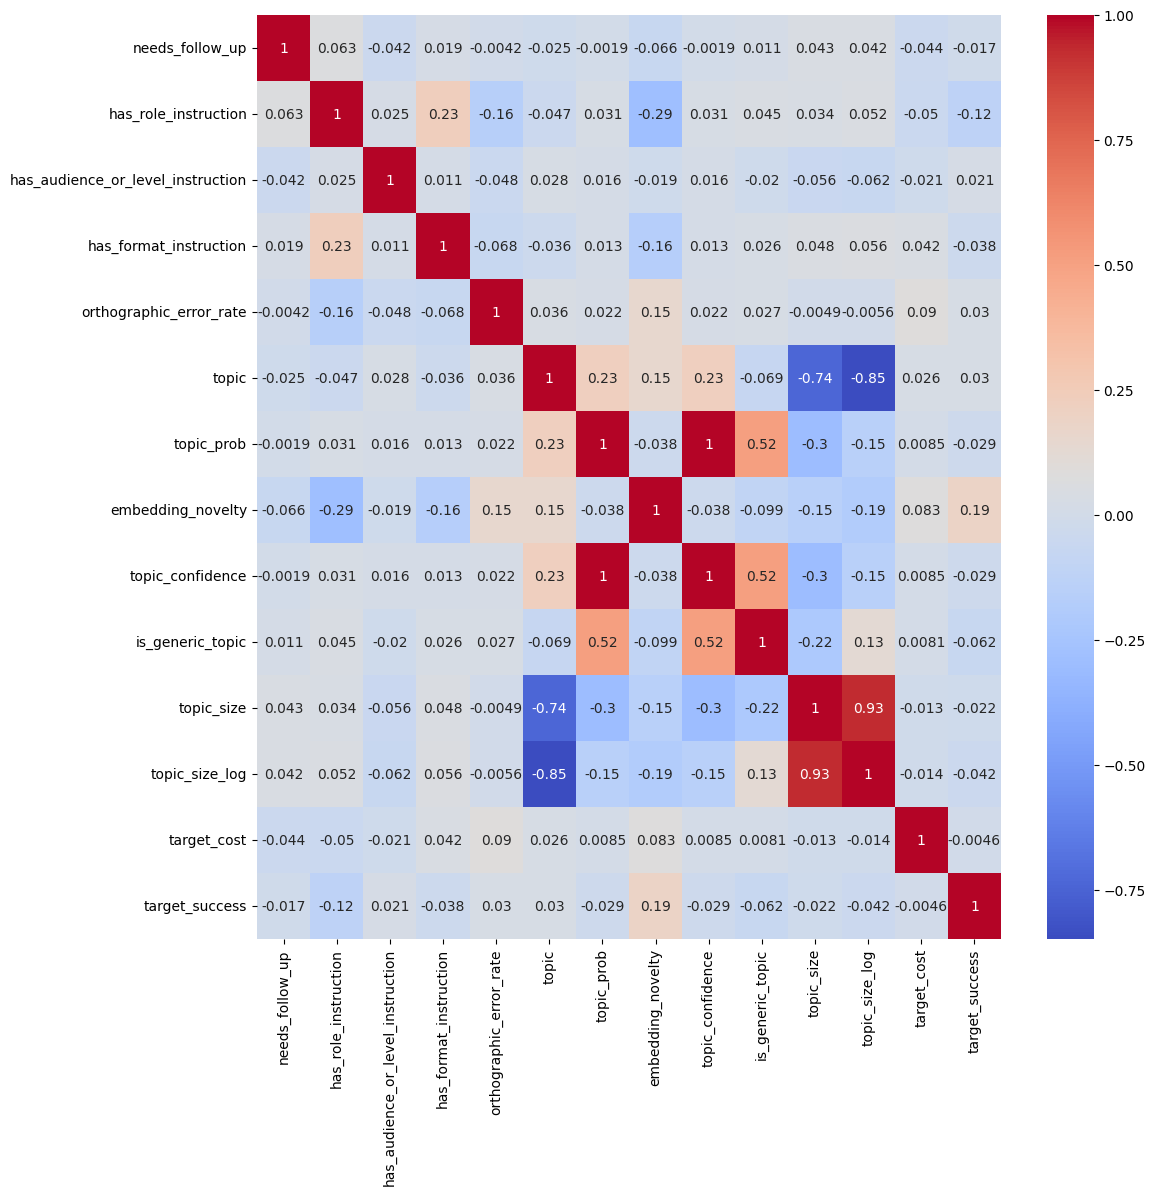

In [26]:
# correlations

fig, ax=plt.subplots(figsize=(12,12))

sns.heatmap(df[['needs_follow_up', 'has_role_instruction',
       'has_audience_or_level_instruction', 'has_format_instruction',
        'orthographic_error_rate', 'topic', 'topic_prob',
       'embedding_novelty', 'topic_confidence', 'is_generic_topic',
       'topic_size', 'topic_size_log', 'target_cost', 'target_success']].corr(), cmap="coolwarm", annot=True)

# train test split

In [27]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

In [28]:
df.columns

Index(['conversation_id', 'first_prompt', 'first_response',
       'first_prompt_tokens', 'first_response_tokens', 'total_turns',
       'interaction_rounds', 'total_user_tokens', 'total_assistant_tokens',
       'total_tokens', 'log_total_tokens', 'follow_up_prompts',
       'needs_follow_up', 'has_role_instruction',
       'has_audience_or_level_instruction', 'has_format_instruction',
       'question_count', 'prompt_style', 'task_type',
       'orthographic_error_rate', 'topic', 'topic_prob', 'topic_label',
       'embedding_novelty', 'topic_confidence', 'is_generic_topic',
       'topic_size', 'topic_size_log', 'target_cost', 'target_success',
       'topic_name', 'target_cost_log'],
      dtype='str')

# feature selection

In [29]:
# features selection v01
  
FEATURES_SELECTED_v01 = {
    'cat': [
        "task_type",
        "topic_name",
        "prompt_style"      
        ],
    'num': [
        "embedding_novelty",
        "topic_prob",
        "orthographic_error_rate",
        "topic_confidence",
        "topic_size_log"
        ],
    'bin': [
        "has_role_instruction",
        "has_audience_or_level_instruction",
        "has_format_instruction",
        "is_generic_topic"
        ]
}

# drop: question_count, total_turns, interaction_rounds, total_user_tokens, total_assistant_tokens, total_tokens, log_total_tokens

# baseline RandomForestClassifier modell "target_success"

In [30]:
# flat features dictionary
features_cols = (
    FEATURES_SELECTED_v01['cat']
    + FEATURES_SELECTED_v01['num']
    + FEATURES_SELECTED_v01['bin']
)

# preprocess
preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", FEATURES_SELECTED_v01['num']),
        ("bin", "passthrough", FEATURES_SELECTED_v01['bin']),
        ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_SELECTED_v01['cat']),
    ],
    remainder="drop"
)

# model
model_rfc_01 = RandomForestClassifier(random_state=42, class_weight="balanced") 

# pipeline
pipeline = Pipeline([
    ("preprocess", preprocess), 
    ("model", model_rfc_01)
])

# fit model
pipeline.fit(df_train[features_cols], df_train["target_success"])    

# predict test
target_test_success_pred = pipeline.predict(df_test[features_cols])
target_test_success_proba = pipeline.predict_proba(df_test[features_cols])[:, 1]

# metrics
print("Accuracy:", accuracy_score(df_test["target_success"], target_test_success_pred))
print("f1_score:", f1_score(df_test["target_success"], target_test_success_pred))
print("ROC AUC:", roc_auc_score(df_test["target_success"], target_test_success_proba))

Accuracy: 0.8808213193534294
f1_score: 0.9341062801932367
ROC AUC: 0.7805725705554155


In [31]:
# names of features

model = pipeline.named_steps["model"]
preprocess = pipeline.named_steps["preprocess"]

feature_names = preprocess.get_feature_names_out()

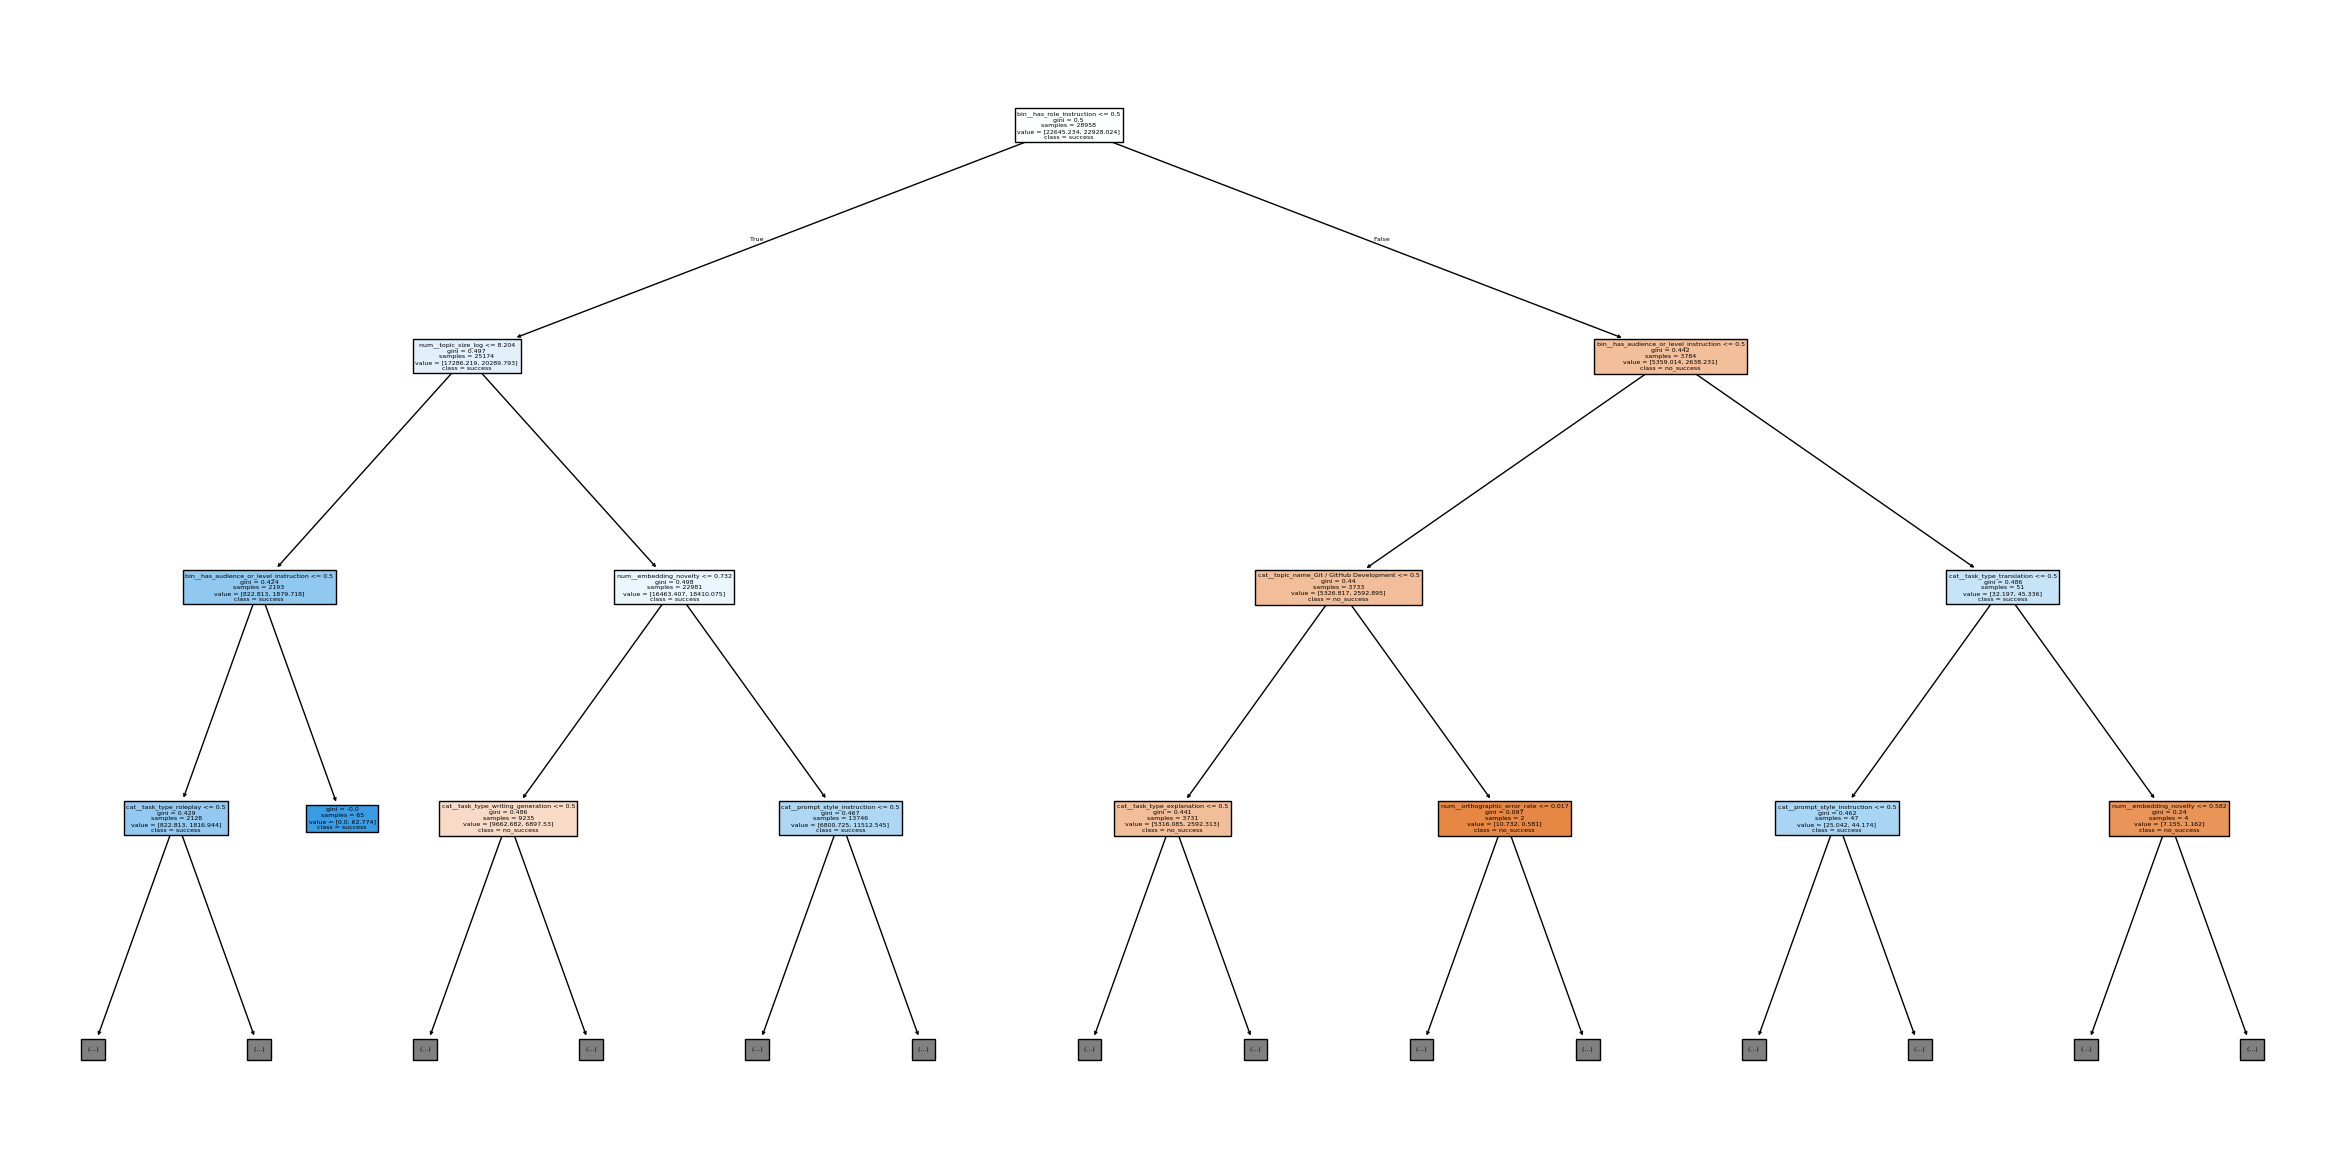

In [32]:
# plot tree

tree = model.estimators_[0]

plt.figure(figsize=(30, 15))

plot_tree(
    tree,
    feature_names=feature_names,
    class_names=["no_success", "success"],
    filled=True,
    max_depth=3
)

plt.show()

In [33]:
importances = model.feature_importances_

fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

fi.head(20)

,feature,importance
0,num__embedding_novelty,0.31
3,num__topic_confidence,0.18
1,num__topic_prob,0.18
2,num__orthographic_error_rate,0.16
7,bin__has_format_instruction,0.02
5,bin__has_role_instruction,0.02
29,cat__prompt_style_question,0.01
28,cat__prompt_style_other,0.01
4,num__topic_size_log,0.01
17,cat__task_type_writing_generation,0.01


# permutation importances

In [43]:
perm_result = permutation_importance(
    pipeline,
    df_test[features_cols],
    df_test["target_success"],
    n_repeats=10,
    scoring='f1', 
    random_state=42,
    n_jobs=-1
)

# feature names
feature_names = df_test[features_cols].columns

# create df
perm_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std
}).sort_values('importance_mean', ascending=False)

perm_df

,feature,importance_mean,importance_std
3,embedding_novelty,0.01,0.00
0,task_type,0.01,0.00
5,orthographic_error_rate,0.01,0.00
2,prompt_style,0.01,0.00
8,has_role_instruction,0.00,0.00
10,has_format_instruction,0.00,0.00
4,topic_prob,0.00,0.00
6,topic_confidence,0.00,0.00
1,topic_name,0.00,0.00
11,is_generic_topic,0.00,0.00


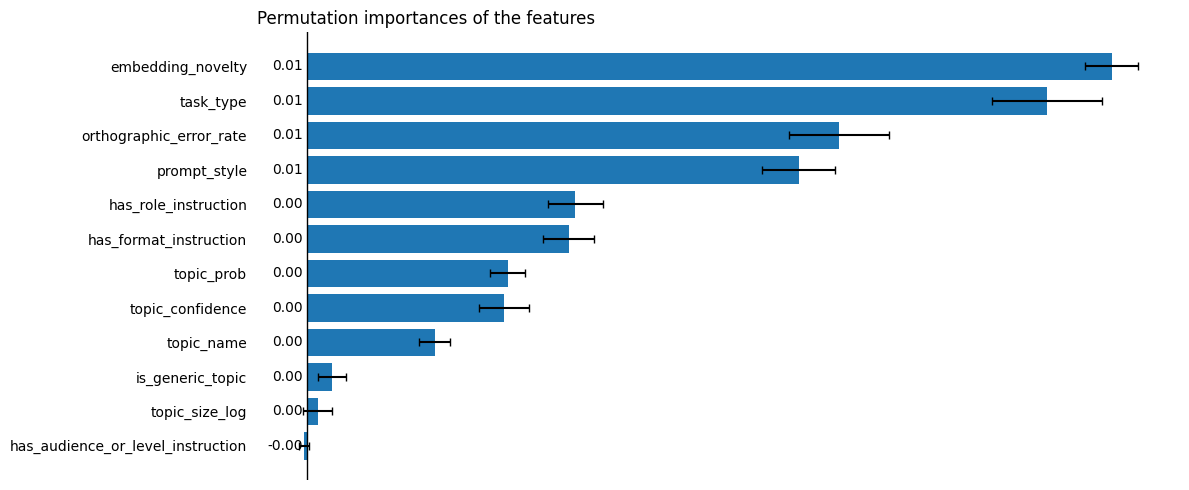

In [42]:
# plot permutation importances

perm_top = perm_df[perm_df['importance_mean'] != 0]
perm_top = perm_top.sort_values(by='importance_mean', ascending=True)

fig, ax = plt.subplots(figsize=(12, 5))


ax.barh(
    perm_top['feature'],
    perm_top['importance_mean']
)

# importance std

ax.errorbar(
    perm_top['importance_mean'],
    perm_top['feature'],
    xerr=perm_top['importance_std'],
    fmt='none',
    ecolor='black',
    capsize=3
)

ax.set_title('Permutation importances of the features', loc='left')
ax.axvline(0, color='black', linewidth=1)

for i, v in enumerate(perm_top['importance_mean']):
    ax.text(
        0.05,  # on the right
        i,
        f'{v:.2f}',
        transform=ax.get_yaxis_transform(),
        ha='right',
        va='center'
    )

ax.tick_params(axis='x', bottom=False, labelbottom=False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks([])
ax.tick_params(left=False)

plt.tight_layout()
plt.show()

# features selection v02

In [45]:
# features selection v01
  
FEATURES_SELECTED_v02 = {
    'cat': [
        "task_type",
        "prompt_style"      
        ],
    'num': [
        "embedding_novelty",
        "orthographic_error_rate"
        ],
    'bin': [
        "has_role_instruction",
        "has_audience_or_level_instruction",
        "has_format_instruction",
        "is_generic_topic"
        ]
}

# drop: "topic_name", "topic_prob", "topic_confidence", "topic_size_log"

In [46]:
# flat features dictionary
features_cols = (
    FEATURES_SELECTED_v02['cat']
    + FEATURES_SELECTED_v02['num']
    + FEATURES_SELECTED_v02['bin']
)

# preprocess
preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", FEATURES_SELECTED_v02['num']),
        ("bin", "passthrough", FEATURES_SELECTED_v02['bin']),
        ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_SELECTED_v02['cat']),
    ],
    remainder="drop"
)

# model
model_rfc_02 = RandomForestClassifier(random_state=42, class_weight="balanced") 

# pipeline
pipeline = Pipeline([
    ("preprocess", preprocess), 
    ("model", model_rfc_02)
])

# fit model
pipeline.fit(df_train[features_cols], df_train["target_success"])    

# predict test
target_test_success_pred = pipeline.predict(df_test[features_cols])
target_test_success_proba = pipeline.predict_proba(df_test[features_cols])[:, 1]

# metrics
print("Accuracy:", accuracy_score(df_test["target_success"], target_test_success_pred))
print("f1_score:", f1_score(df_test["target_success"], target_test_success_pred))
print("ROC AUC:", roc_auc_score(df_test["target_success"], target_test_success_proba))

Accuracy: 0.872083879423329
f1_score: 0.9277179816332576
ROC AUC: 0.759821772012942


In [47]:
# names of features

model = pipeline.named_steps["model"]
preprocess = pipeline.named_steps["preprocess"]

feature_names = preprocess.get_feature_names_out()

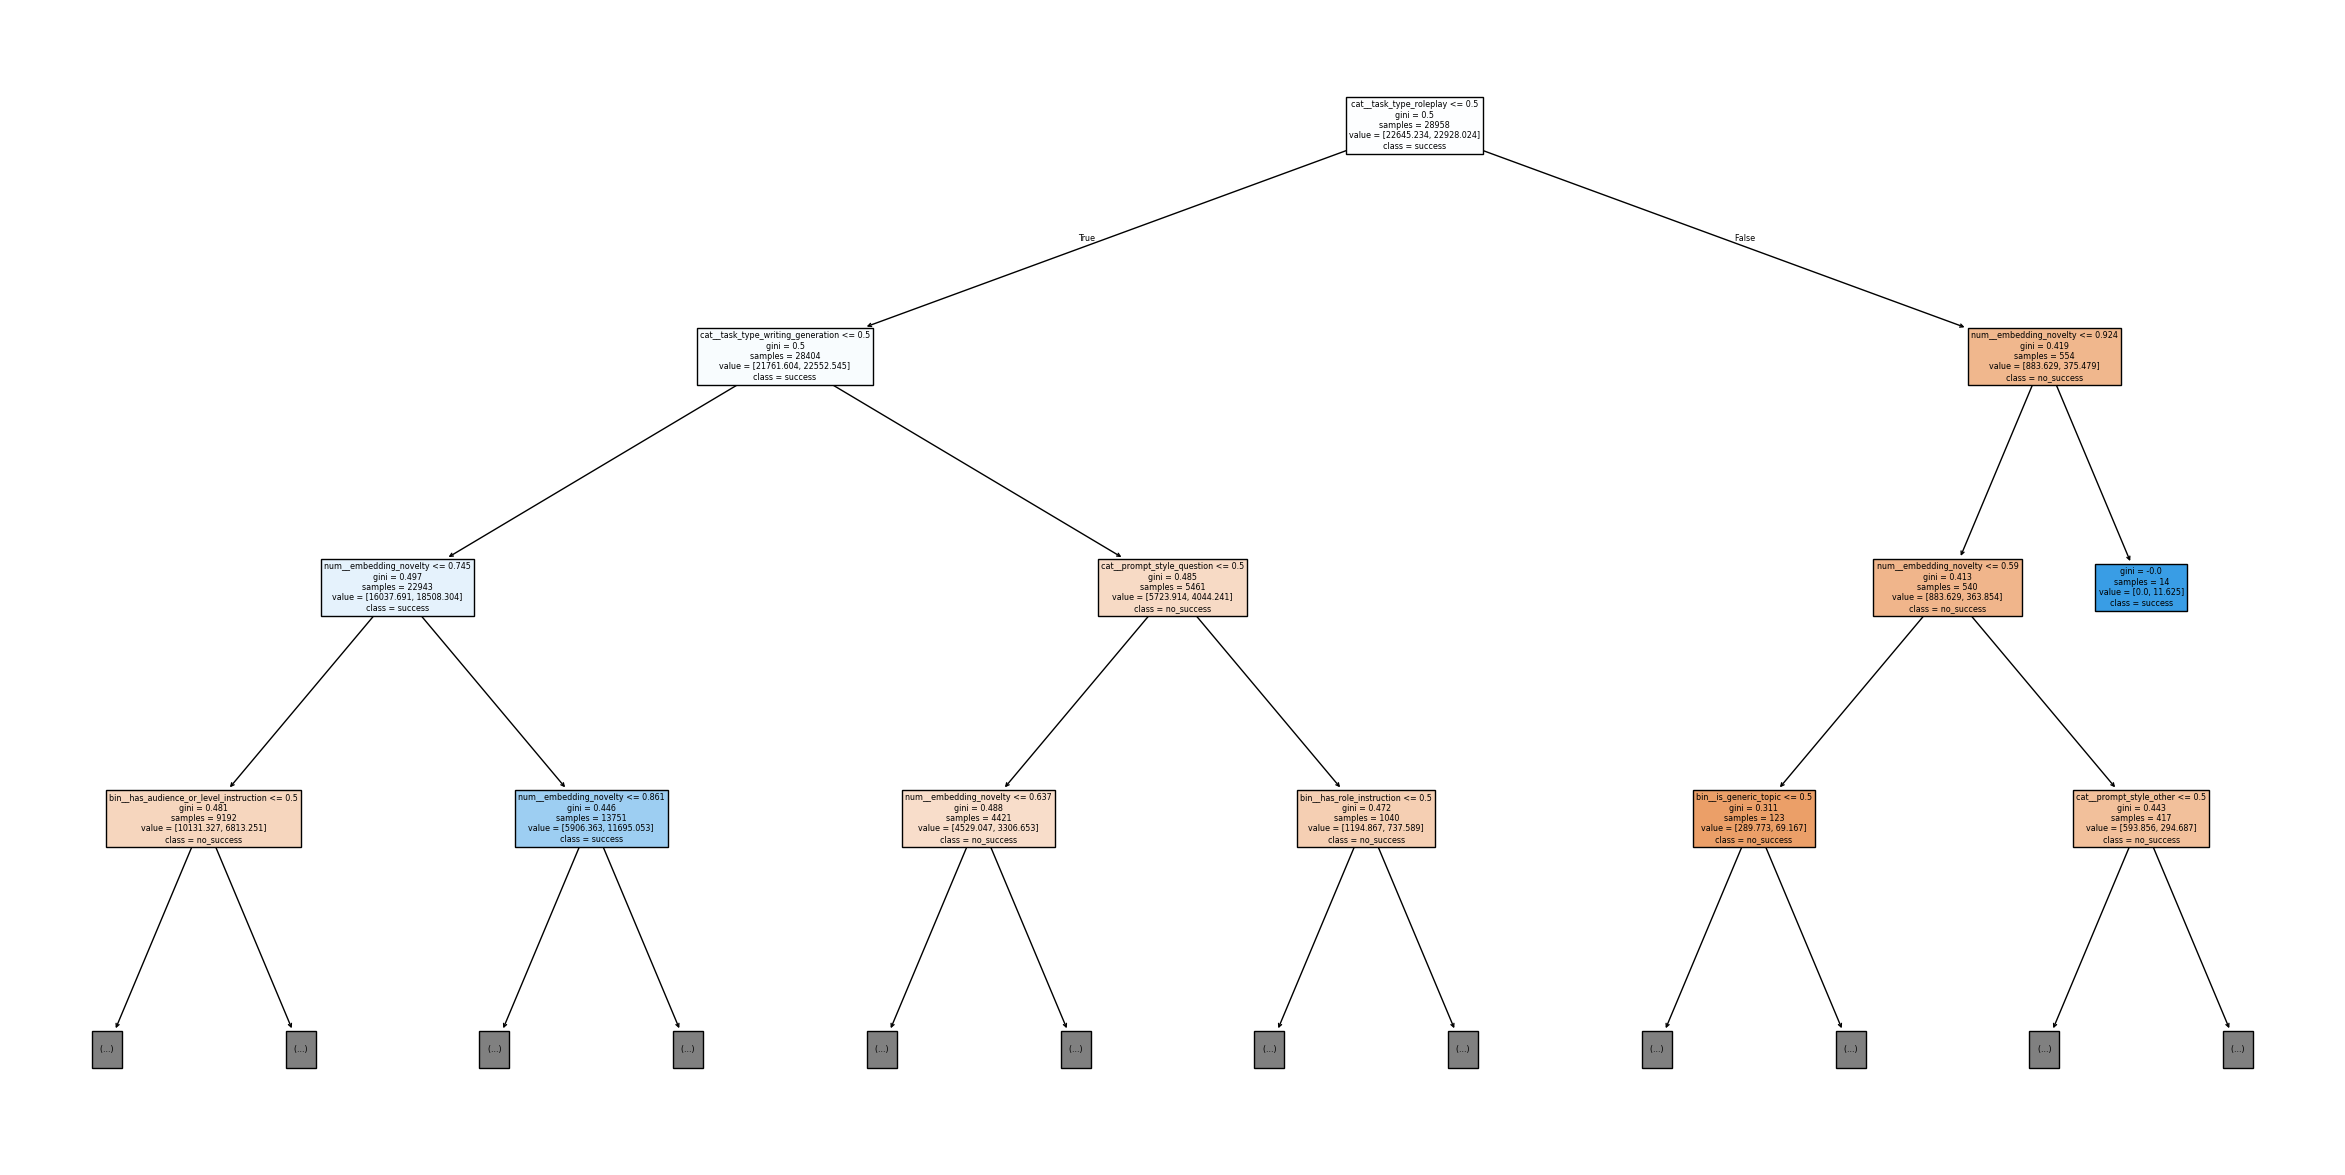

In [48]:
# plot tree

tree = model.estimators_[0]

plt.figure(figsize=(30, 15))

plot_tree(
    tree,
    feature_names=feature_names,
    class_names=["no_success", "success"],
    filled=True,
    max_depth=3
)

plt.show()

In [49]:
importances = model.feature_importances_

fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

fi.head(20)

,feature,importance
0,num__embedding_novelty,0.60
1,num__orthographic_error_rate,0.27
4,bin__has_format_instruction,0.02
2,bin__has_role_instruction,0.02
5,bin__is_generic_topic,0.02
14,cat__task_type_writing_generation,0.01
16,cat__prompt_style_other,0.01
17,cat__prompt_style_question,0.01
9,cat__task_type_explanation,0.01
10,cat__task_type_general_assistance,0.01


# permutation importances

In [50]:
perm_result = permutation_importance(
    pipeline,
    df_test[features_cols],
    df_test["target_success"],
    n_repeats=10,
    scoring='f1', 
    random_state=42,
    n_jobs=-1
)

# feature names
feature_names = df_test[features_cols].columns

# create df
perm_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std
}).sort_values('importance_mean', ascending=False)

perm_df

,feature,importance_mean,importance_std
2,embedding_novelty,0.03,0.00
0,task_type,0.02,0.00
3,orthographic_error_rate,0.02,0.00
1,prompt_style,0.02,0.00
7,is_generic_topic,0.01,0.00
6,has_format_instruction,0.01,0.00
4,has_role_instruction,0.01,0.00
5,has_audience_or_level_instruction,-0.00,0.00


# baseline modell RandomForestRegressor "target_cost"

In [ ]:
# flat features dictionary
features_cols = (
    FEATURES_SELECTED_v01['cat']
    + FEATURES_SELECTED_v01['num']
    + FEATURES_SELECTED_v01['bin']
)

# preprocess
preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", FEATURES_SELECTED_v01['num']),
        ("bin", "passthrough", FEATURES_SELECTED_v01['bin']),
        ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_SELECTED_v01['cat']),
    ],
    remainder="drop"
)

# model
# No sample weighting applied. The log-transformed target variable is approximately normally distributed.
# and does not exhibit severe target imbalance.

model_rfr_02 = RandomForestRegressor(random_state=42, n_jobs=-1)  

# pipeline
pipeline = Pipeline([
    ("preprocess", preprocess), 
    ("model", model_rfr_02)
])

# fit model
pipeline.fit(
    df_train[features_cols],
    df_train["target_cost_log"]
)

# predict test
target_test_cost_log_pred = pipeline.predict(df_test[features_cols])

# metrics
print("R2 Score:", r2_score(df_test["target_cost_log"], target_test_cost_log_pred))

R2 Score: 0.10760755982425951


In [23]:
# names of features

model = pipeline.named_steps["model"]
preprocess = pipeline.named_steps["preprocess"]

feature_names = preprocess.get_feature_names_out()

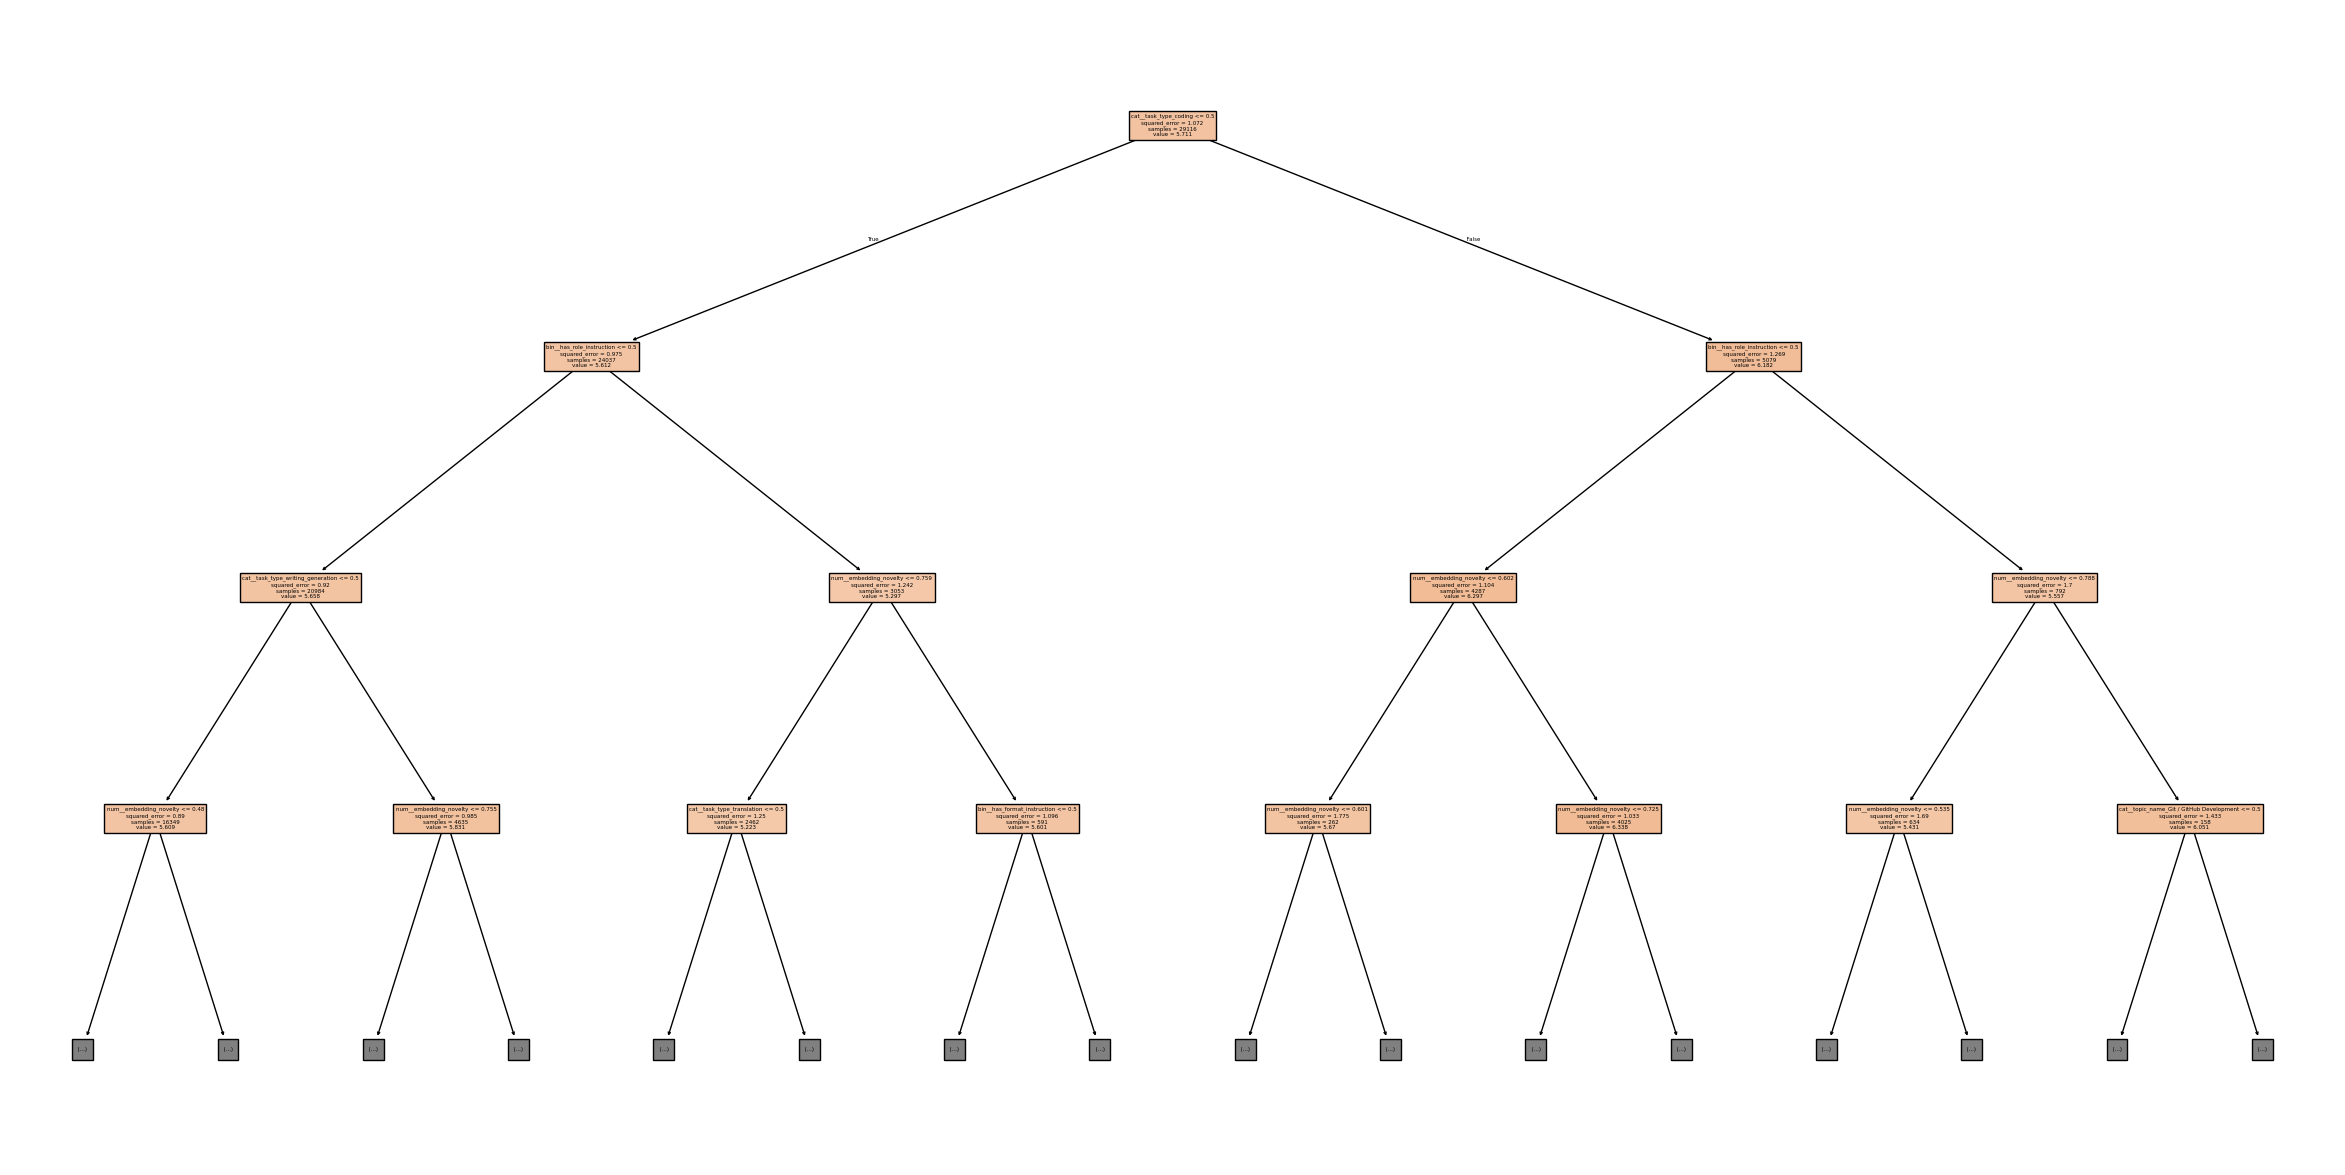

In [24]:
tree = model.estimators_[0]

plt.figure(figsize=(30, 15))

plot_tree(
    tree,
    feature_names=feature_names,
    class_names=["low cost", "high cost"],
    filled=True,
    max_depth=3
)

plt.show()